In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# load data 
file_path = os.path.join("tables", "exerciseTableForBN_python_processed.csv")
exerciseTable = pd.read_csv(file_path)


tiers = {
    'static': ['age', 'gender', 'diabetesDuration', 'BMI', 'HbA1c', 'InsSensitivity', 'InsCarbRatio', 'avgSessionsPerWeek'],
    'pre': ['preExerciseRoc', 'startExerciseGlucoseLevel', 'preExerciseGlucoseCV', 'IOBnormStartEx', 'COBnormStartEx', 'AOB', 'TotalCWL'],
    'exercise' : ['MET', 'DurationValue', 'ExerciseModality', 'CHODuringEx', 'InsulinDuringEx'],
    #'exercise' : ['MET_min', 'ExerciseModality'],
   'end_exercise' : ['endExerciseGlucoseLevel', 'IOBnormEndEx', 'COBnormEndEx'],
    #'outcome_during': ['exerciseMaxExcursion', 'exerciseMaxSpikeRoc', 'exerciseMaxDropRoc', 'exerciseNadir', 'exercisePeak', 'exerciseTIR', 'exerciseTBR', 'exerciseAUC70'],
    #'outcome_post': ['maxGlucosePostExercise', 'minGlucosePostExercise','postExerciseTimeToNadir', 'postExerciseTIR','postExerciseTBR','postExerciseTAR', 'postExerciseGlucoseCV', 'postExerciseAUC70', 'postExerciseHypoEvent']
}
all_features = exerciseTable.columns.tolist()
features_to_drop = set(all_features) - set(sum(tiers.values(), []))

outcome = 'postExerciseHypoEvent'

df = exerciseTable.drop(columns=features_to_drop)
df['PtID'] = exerciseTable['PtID']
df[outcome] = exerciseTable[outcome]


/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

--- MODEL PERFORMANCE COMPARISON ---

[Logistic Regression]
Accuracy: 0.76 | ROC-AUC: 0.78
----------------------------------------
[Random Forest]
Accuracy: 0.76 | ROC-AUC: 0.75
----------------------------------------
[XGBoost]
Accuracy: 0.76 | ROC-AUC: 0.75
----------------------------------------


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-

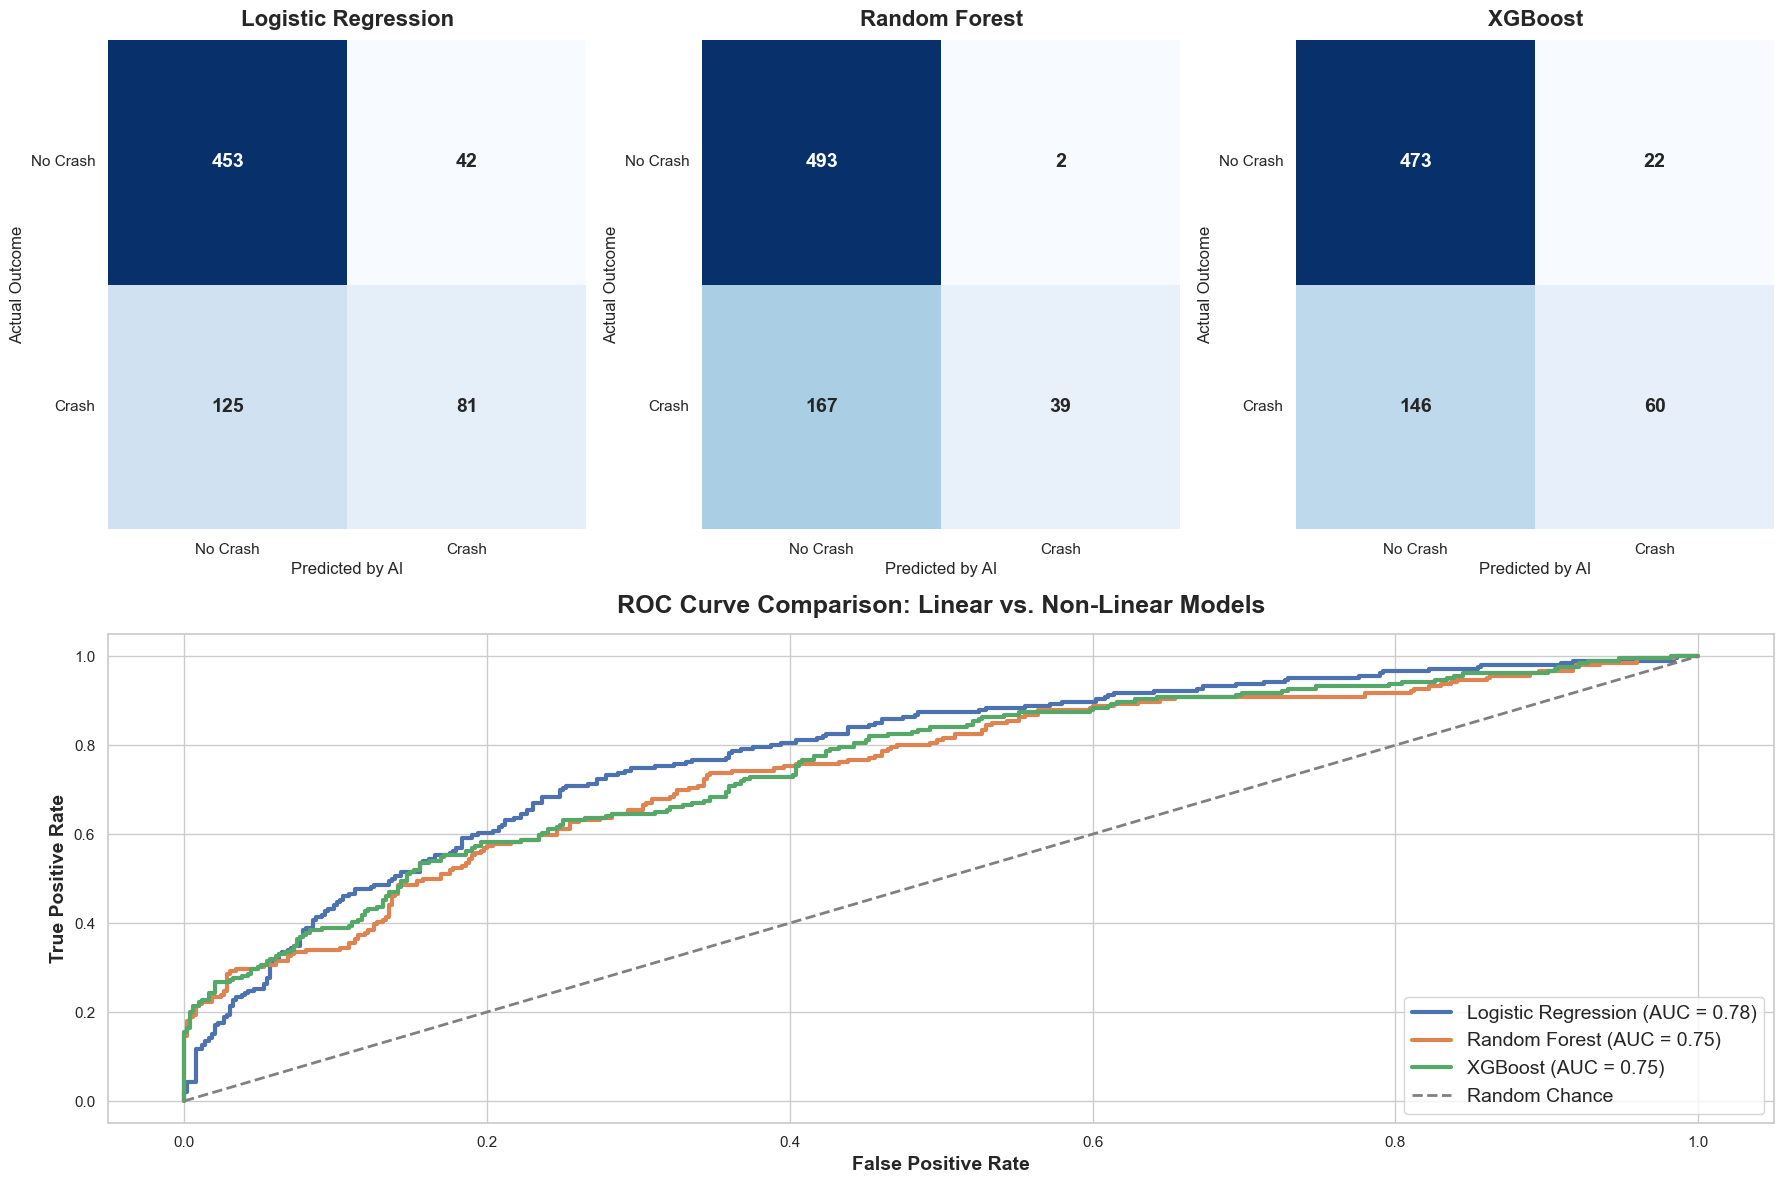

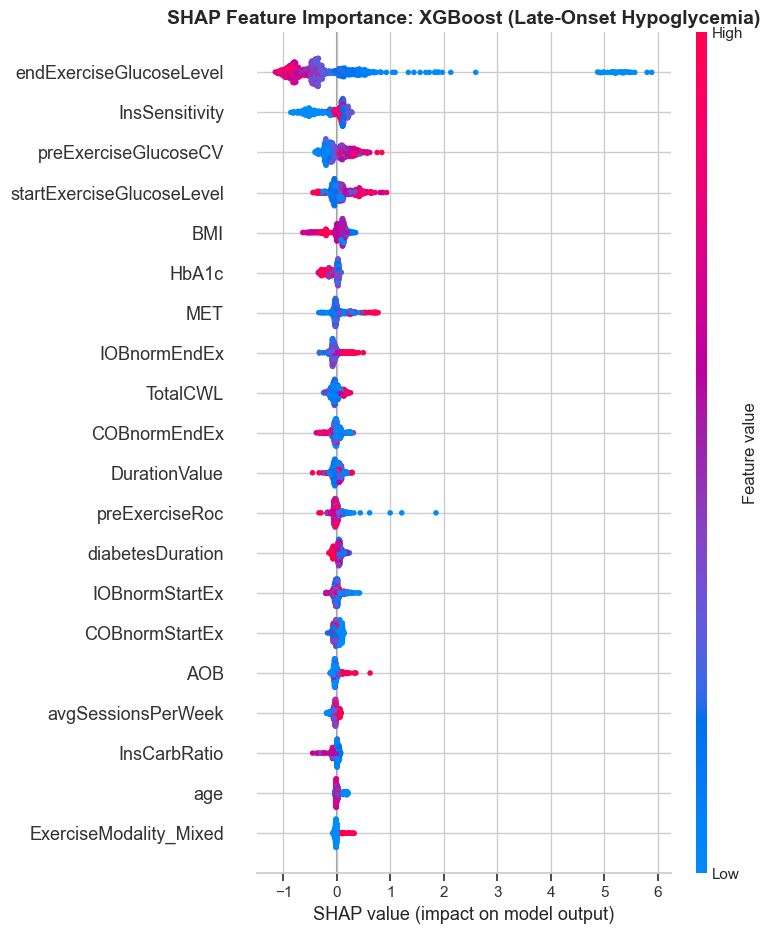

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, auc)

# =====================================================================
# 1. Prepare the Data
# =====================================================================
df_ml = pd.get_dummies(df, drop_first=True)

target_col = 'postExerciseHypoEvent_Yes' 
if target_col not in df_ml.columns:
    target_col = 'postExerciseHypoEvent' 

y = df_ml[target_col]
X = df_ml.drop(columns=[target_col, 'PtID'])

groups = df_ml['PtID']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# IMPORTANT: Logistic Regression requires scaled data to converge properly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 2. Initialize and Train All 3 Models
# =====================================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

# Train them all
models["Logistic Regression"].fit(X_train_scaled, y_train)
models["Random Forest"].fit(X_train, y_train)
models["XGBoost"].fit(X_train, y_train)

# =====================================================================
# 3. Print Performance Metrics
# =====================================================================
print("--- MODEL PERFORMANCE COMPARISON ---\n")
for name, model in models.items():
    # Use scaled data for LR, normal data for trees
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    
    print(f"[{name}]")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f} | ROC-AUC: {roc_auc_score(y_test, y_proba):.2f}")
    print("-" * 40)

# =====================================================================
# 4. Visualize Results (3 Confusion Matrices + 1 Combined ROC)
# =====================================================================
sns.set_theme(style="whitegrid")

# Create a 2-row layout: Top row for Confusion Matrices, Bottom row for ROC
fig = plt.figure(figsize=(18, 12))
ax1 = plt.subplot(2, 3, 1)
ax2 = plt.subplot(2, 3, 2)
ax3 = plt.subplot(2, 3, 3)
ax4 = plt.subplot(2, 1, 2) # ROC takes up the whole bottom row

cm_axes = [ax1, ax2, ax3]

for i, (name, model) in enumerate(models.items()):
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    
    # --- Plot Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=cm_axes[i],
                cbar=False, annot_kws={"size": 14, "weight": "bold"})
    cm_axes[i].set_title(f'{name}', fontsize=16, fontweight='bold', pad=10)
    cm_axes[i].set_xlabel('Predicted by AI', fontsize=12)
    cm_axes[i].set_ylabel('Actual Outcome', fontsize=12)
    cm_axes[i].set_xticklabels(['No Crash', 'Crash'], fontsize=11)
    cm_axes[i].set_yticklabels(['No Crash', 'Crash'], fontsize=11, rotation=0)

    # --- Plot ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax4.plot(fpr, tpr, lw=3, label=f'{name} (AUC = {roc_auc:.2f})')

# Finish ROC Plot formatting
ax4.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Chance')
ax4.set_title('ROC Curve Comparison: Linear vs. Non-Linear Models', fontsize=18, fontweight='bold', pad=15)
ax4.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax4.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
ax4.legend(loc="lower right", fontsize=14)

plt.tight_layout()
plt.savefig("Model_Comparison_Plots.png", dpi=300)
plt.show()

# =====================================================================
# 5. Calculate and Plot SHAP Values (Still using XGBoost as the winner)
# =====================================================================
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance: XGBoost (Late-Onset Hypoglycemia)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.show()